In [25]:
import pandas as pd
import os

In [31]:
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')

base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]
scenario_results = {}

# STAP 1: Eerst alle data verzamelen en de ruwe impact berekenen
all_dfs = []
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    scenario_df = pd.read_csv(file_path)

    merged_df = pd.merge(
        scenario_df[['Seed', 'Total_Delay']],
        base_subset,
        left_on='Seed',
        right_on='id'
    ).drop(columns=['Seed'])[['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon']]

    # Bereken de ruwe impact (Delay * Trucks)
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i  # Handig om later te weten welk scenario dit was

    all_dfs.append(merged_df)

# STAP 2: Bereken de globale Min en Max over alle 12 scenario's heen
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

# STAP 3: De scaling toepassen en de resultaten opslaan
for i, df in enumerate(all_dfs):
    # Pas de scaling toe op basis van de globale uitersten
    df['impact_scaled'] = (df['impact_raw'] - global_min) / (global_max - global_min)

    # Sorteer zodat de meest kritieke punten (top 20) bovenaan staan
    #df = df.sort_values(by='impact_scaled', ascending=False)

    # Sla op in dictionary en als losse variabelen (df_0, df_1, etc.)
    scenario_results[f'scenario_{i}'] = df
    globals()[f'df_{i}'] = df

print(f"Check: df_0 is klaar. Globale max was {global_max:.2f}")
print(df_0[['id', 'impact_raw', 'impact_scaled']].head(5))

Check: df_0 is klaar. Globale max was 32100463.22
       id    impact_raw  impact_scaled
0  100009  6.314906e+06       0.196493
1  100015  6.372160e+06       0.198277
2  100057  9.329203e+06       0.290422
3  100061  2.314534e+07       0.720948
4  100077  9.793418e+06       0.304887


In [34]:
#aantal rijen die je hebt is aantal bruggen die kapot zijn gegaan
count_bridges = len(base_df[base_df['model_type'] == 'bridge'])

print(f"Amount bridges: {count_bridges}")

Amount bridges: 1434


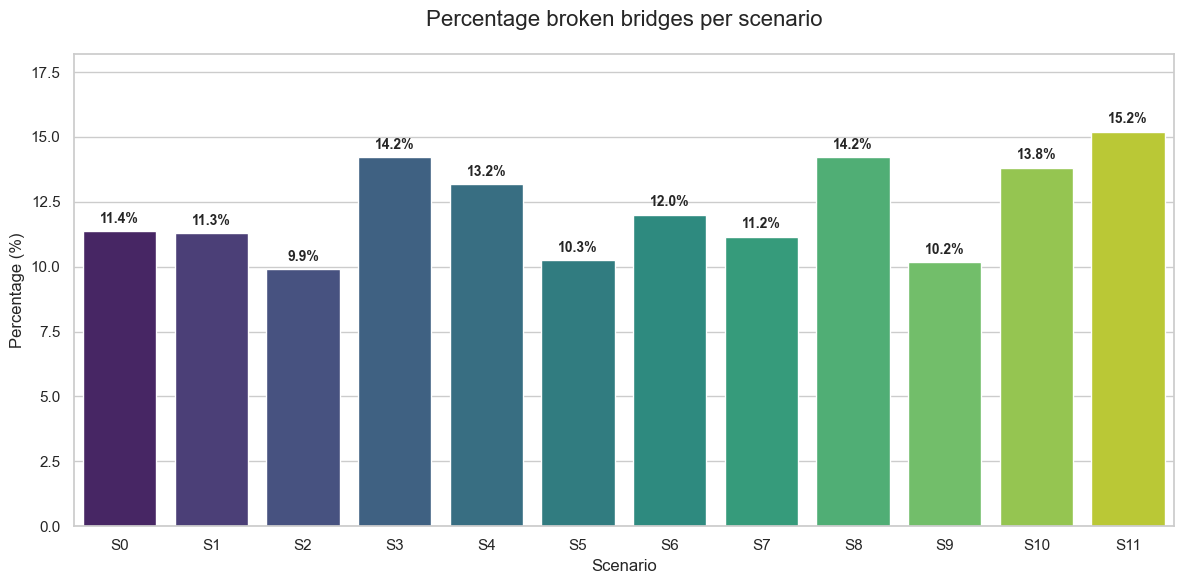

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

scenarios = [df_0, df_1, df_2, df_3, df_4, df_5, df_6, df_7, df_8, df_9, df_10, df_11]

# Bereken percentages en maak labels
percentages = [(len(df) / count_bridges) * 100 for df in scenarios]
labels = [f"S{i}" for i in range(len(scenarios))]

# Maak een DataFrame die Seaborn begrijpt
plot_df = pd.DataFrame({
    'Scenario': labels,
    'Percentage': percentages
})

# 2. Plotten
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Maak de bar chart
ax = sns.barplot(x='Scenario', y='Percentage', data=plot_df, palette='viridis', hue='Scenario', legend=False)

# 3. Styling en labels
plt.title('Percentage broken bridges per scenario', fontsize=16, pad=20)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Scenario', fontsize=12)
plt.ylim(0, max(percentages) + 3) # Extra ruimte bovenin voor de tekst

# Voeg de tekstlabels (de cijfers) boven de balken toe
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()
plt.show()

In [41]:
#average impact raw over alle 12 scenarios, en dan je meest kritieke bruggen

15.202231520223153


In [47]:
combined_df = pd.concat(scenarios)

avg_impact_per_bridge = combined_df.groupby('id').agg({
    'impact_scaled': 'mean',
    'impact_raw': 'mean',
    'avg_truck_AADT': 'first',
    'lat': 'first',
    'lon': 'first',
    'scenario_id': lambda x: list(x)
}).rename(columns={'scenario_id': 'scenarios_found'})

avg_impact_per_bridge['occurrence_count'] = avg_impact_per_bridge['scenarios_found'].apply(len)

avg_impact_per_bridge = avg_impact_per_bridge.sort_values(by='impact_scaled', ascending=False)

print("Top 20 most critical bridges:")

avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].head(20)

Top 20 most critical bridges:


,impact_scaled,occurrence_count,scenarios_found
id,,,
100139,0.850423,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100141,0.834198,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100145,0.820455,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100067,0.755383,6,"[3, 4, 6, 8, 10, 11]"
100231,0.745372,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100061,0.722557,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100085,0.700958,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100101,0.681019,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100359,0.556730,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


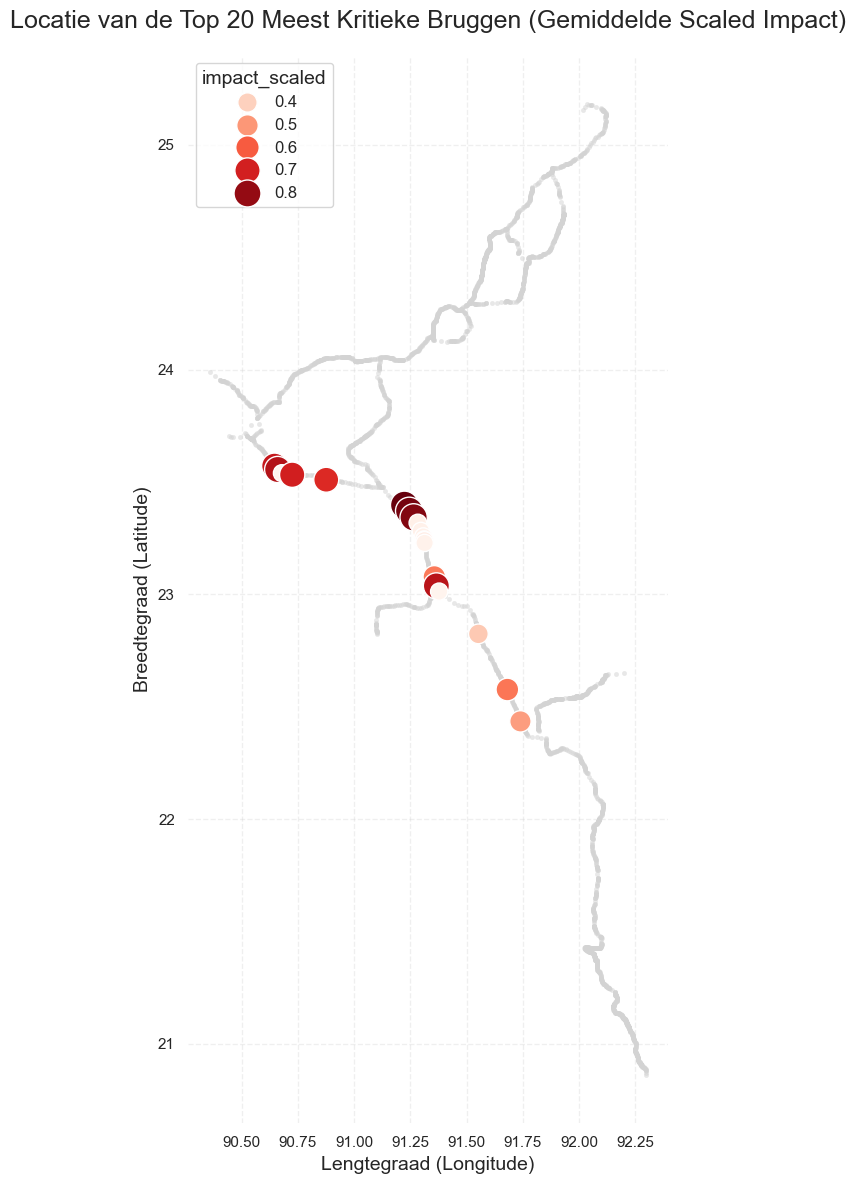

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Haal de top 20 IDs op uit je gesorteerde gemiddelde impact tabel
top_20_avg_df = avg_impact_per_bridge.head(20).copy()
# Omdat 'id' de index is, maken we er weer een kolom van voor de merge
top_20_avg_df = top_20_avg_df.reset_index()
top_20_ids = top_20_avg_df['id'].unique()

# 2. Data voorbereiden voor plotten
# We maken een kopie van het hele netwerk
plot_netwerk_df = base_df.copy()

# We markeren welke elementen bij de top 20 horen en welke niet
plot_netwerk_df['Status'] = 'Overig Netwerk'
plot_netwerk_df.loc[plot_netwerk_df['id'].isin(top_20_ids), 'Status'] = 'Top 20 Kritiek'

# Voor een betere visualisatie voegen we de impact_scaled score toe aan de top 20 bruggen in het plot_df
# We mergen dit alleen voor de top 20 om NaN's voor de rest te krijgen
plot_netwerk_df = pd.merge(plot_netwerk_df,
                           top_20_avg_df[['id', 'impact_scaled']],
                           on='id',
                           how='left')

# 3. Het Kaartje Plotten met Seaborn
sns.set_theme(style="white")
plt.figure(figsize=(15, 12))

# --- Laag 1: Het hele netwerk als lichtgrijze stipjes/lijnen ---
g = sns.scatterplot(data=plot_netwerk_df[plot_netwerk_df['Status'] == 'Overig Netwerk'],
                    x='lon', y='lat',
                    color='#d3d3d3', # Lichtgrijs
                    s=10,
                    alpha=0.5,
                    edgecolor=None,
                    legend=False)

# --- Laag 2: De Top 20 Bruggen ---
# We gebruiken 'hue' voor de schaal en 'size' voor de nadruk
top_20_data = plot_netwerk_df[plot_netwerk_df['Status'] == 'Top 20 Kritiek']
top_20_plot = sns.scatterplot(data=top_20_data,
                              x='lon', y='lat',
                              hue='impact_scaled',
                              palette='Reds', # Kleurverloop van geel naar rood
                              size='impact_scaled',
                              sizes=(150, 400), # Grootte bereik van de markers
                              legend='brief') # 'brief' voor een mooie legenda

# 4. Styling en Layout
# Zorg dat de assen niet vervormen (een graad breedte is niet gelijk aan een graad lengte)
plt.gca().set_aspect('equal', adjustable='box')

plt.title('Locatie van de Top 20 Meest Kritieke Bruggen (Gemiddelde Scaled Impact)', fontsize=18, pad=20)
plt.xlabel('Lengtegraad (Longitude)', fontsize=14)
plt.ylabel('Breedtegraad (Latitude)', fontsize=14)

# Legenda aanpassen
plt.setp(top_20_plot.get_legend().get_texts(), fontsize='12')
plt.setp(top_20_plot.get_legend().get_title(), fontsize='14')

sns.despine(left=True, bottom=True) # Verwijder de assen-randjes
plt.grid(True, linestyle='--', alpha=0.3) # Voeg een subtiel raster toe

plt.tight_layout()
plt.show()